# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.
2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.
3. Implement an ~80/~20 train-test split. Put the test data aside.
4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?
5. Include transformations and interactions, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?
6. Summarize your results from 1 to 5. Have you learned anything about overfitting and underfitting, or model selection?
7. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.



In [21]:
! git clone https://github.com/jonahcic/linearRegression

fatal: destination path 'linearRegression' already exists and is not an empty directory.


   Unnamed: 0        Make  Make_Year   Color  Body_Type  Mileage_Run  \
0           1  Volkswagen       2017  silver      sedan        44611   
1           2     Hyundai       2016     red  crossover        20305   
2           3       Honda       2019   white        suv        29540   
3           4     Renault       2017  bronze  hatchback        35680   
4           5     Hyundai       2017  orange  hatchback        25126   

  No_of_Owners  Seating_Capacity Fuel_Type Transmission Transmission_Type  \
0          1st                 5    diesel      7-Speed         Automatic   
1          1st                 5    petrol      5-Speed            Manual   
2          2nd                 5    petrol      5-Speed            Manual   
3          1st                 5    petrol      5-Speed            Manual   
4          1st                 5    petrol      5-Speed            Manual   

    Price  
0  657000  
1  682000  
2  793000  
3  414000  
4  515000   

       Unnamed: 0    Make_Year

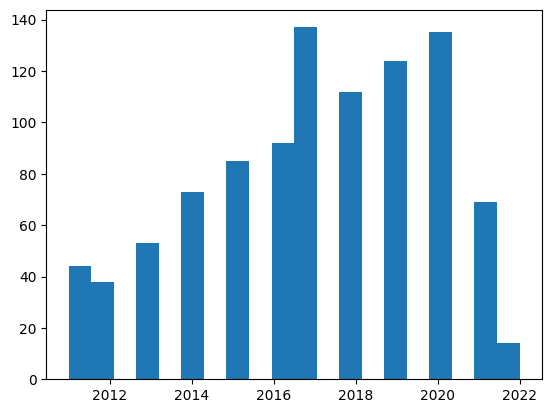

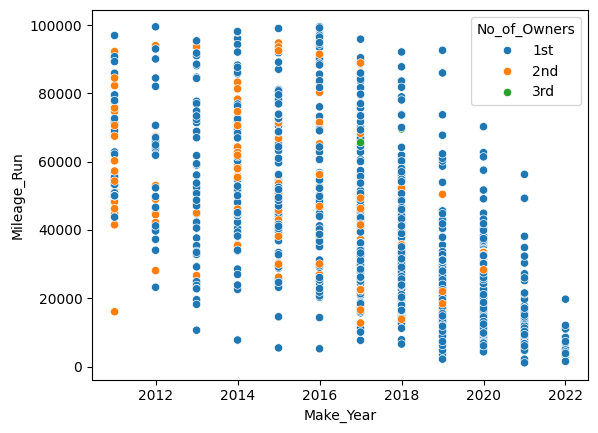

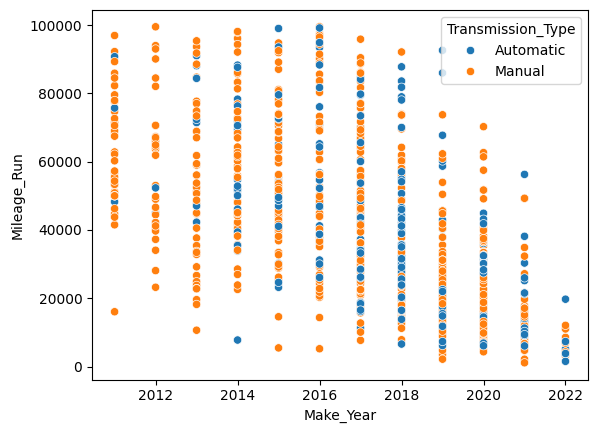

   Make_Year  Mileage_Run No_of_Owners Transmission_Type
0       2017        44611          1st         Automatic
1       2016        20305          1st            Manual
2       2019        29540          2nd            Manual
3       2017        35680          1st            Manual
4       2017        25126          1st            Manual 



In [84]:
### 1

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("/content/linearRegression/04_hedonic_pricing/cars_hw.csv")
print(df.head(),"\n")
print(df.describe(),"\n")
df['Make_Year'].hist(bins=20,grid=False)
plt.show()
sns.scatterplot(data=df,y="Mileage_Run",x="Make_Year",hue='No_of_Owners')
plt.show()
sns.scatterplot(data=df,y="Mileage_Run",x="Make_Year",hue='Transmission_Type')
plt.show()

df_interest = df.drop(["Unnamed: 0","Make","Color","Body_Type","Seating_Capacity","Transmission","Fuel_Type","Price"],axis=1)
print(df_interest.head(),"\n")

In [85]:
### 2 & 3

from sklearn.model_selection import train_test_split

y = df_interest["Mileage_Run"]
X = df_interest.loc[:,["Make_Year", "No_of_Owners", "Transmission_Type"]]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=.2, random_state=100)

Z_train = pd.concat([X_train["Make_Year"],pd.get_dummies(X_train["No_of_Owners"], dtype="int"),pd.get_dummies(X_train["Transmission_Type"], dtype="int")],axis = 1)
Z_test = pd.concat([X_test["Make_Year"],pd.get_dummies(X_test["No_of_Owners"], dtype="int"),pd.get_dummies(X_test["Transmission_Type"], dtype="int")],axis = 1)

In [86]:
### 4

from sklearn.linear_model import LinearRegression

# regressing Mileage Run on Make Year (numerical)

var_n = ["Make_Year"]
X_train_n = Z_train.loc[:,var_n]
reg_n = LinearRegression().fit(X_train_n,y_train)
X_test_n = Z_test.loc[:,var_n]
y_hat = reg_n.predict(X_test_n)
rmse_n = np.sqrt( np.mean( (y_test - y_hat)**2 ))
print('Numeric only R-squared: ', reg_n.score(X_test_n,y_test))
print('Numeric only RMSE: ', rmse_n)

# regressing Mileage Run on Number of Owners and Fuel Type (categorical)

N = df_interest.shape[0]
train_size = int(.8*N)
var_c = ["No_of_Owners","Transmission_Type"]
dummies = pd.DataFrame([])
for var in var_c:
    new_dummies = pd.get_dummies( df.loc[:,var], drop_first=True, dtype=int)
    dummies = pd.concat([dummies, new_dummies], axis=1, ignore_index=True)
    X_train_c = dummies.iloc[0:train_size,:]
    X_test_c = dummies.iloc[train_size:,:]
reg_c = LinearRegression().fit(X_train_c,y_train)
y_hat_c = reg_c.predict(X_test_c)
rmse_c = np.sqrt( np.mean( (y_test - y_hat_c)**2 ))
print('Categorical only R-squared: ', reg_c.score(X_test_c,y_test))
print('Categorical only RMSE: ', rmse_c)

# regressing Mileage Run on All Variables of Interest

reg = LinearRegression(fit_intercept=False).fit(Z_train,y_train)

y_hat = reg.predict(Z_test)
rmse = np.sqrt( np.mean( (y_test - y_hat)**2 ))
print('R-squared: ', reg.score(Z_test,y_test))
print('RMSE: ', rmse)

Numeric only R-squared:  0.29876093567129147
Numeric only RMSE:  20115.69912543488
Categorical only R-squared:  -0.01619855115012614
Categorical only RMSE:  24215.384318837223
R-squared:  0.30201365954110637
RMSE:  20068.991183486254


The model which takes all the variables of interest (categorical and numerical) has the highest R-squared value, however the difference between it and the numerical-only model is very small, leading me to believe the categorical variables of interest have little effect on the model.

In [93]:
### 5

y = df_interest["Mileage_Run"]
df_interest["OwnersXTransmissionType"] = df_interest["No_of_Owners"].astype("str")+"X"+df_interest["Transmission_Type"].astype("str")
X = df_interest.loc[:,["Mileage_Run", "Make_Year", "OwnersXTransmissionType"] ]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.2,random_state=1)

Z_train = pd.concat([X_train["Make_Year"],pd.get_dummies(X_train["OwnersXTransmissionType"], dtype="int")],axis = 1)
Z_test = pd.concat([X_test["Make_Year"],pd.get_dummies(X_test["OwnersXTransmissionType"], dtype="int")],axis = 1)

reg = LinearRegression(fit_intercept=False).fit(Z_train,y_train)

y_hat = reg.predict(Z_test)
rmse = np.sqrt( np.mean( (y_test - y_hat)**2 ))
print('R-squared: ', reg.score(Z_test,y_test))
print('RMSE: ', rmse)

R-squared:  0.31230921196094363
RMSE:  19857.27789119158


The complex model has a slightly higher R-squared value of 0.31 compared to the simpler model's 0.30. This shows that the complexity does not improve the model significantly. However, this may be useful in comparing the different transmission types with number of owners against the mileage more specifically, since we can now get the coefficients for specific combinations, such as a automatic with two owners.

### 6.

I've learned that with linear regression, numeric variables tend to have greater influence on the model's performance than categorical variables, which makes sense. I've also realized that adding complexity does not necessarily make a better model. While underfitting is a problem without enough variables being considered, overfitting is also a significant issue, so it is important in practice to find the best performing balance between complexity and simplicity, in order to develop the most accurate models.

### 7.

N/A, did not have time for question 7.